In [1]:
import pandas as pd

complaints = {
    "Complaint": [
        "Transaction failed but amount was deducted.",
        "Loan approval process is very slow.",
        "Unable to login to online banking.",
        "ATM did not dispense cash but account was debited.",
        "Credit card payment is not reflecting.",
        "Internet banking server is always down.",
        "Customer service is not responding.",
        "Need faster loan processing.",
        "Debit card is blocked without any reason.",
        "Mobile banking app crashes frequently.",
        "Account balance is incorrect.",
        "Cheque clearance takes too much time.",
        "Net banking password reset is not working.",
        "UPI payment failed multiple times.",
        "Bank staff are very helpful and polite."
    ]
}

df = pd.DataFrame(complaints)

df.head()

,Complaint
0,Transaction failed but amount was deducted.
1,Loan approval process is very slow.
2,Unable to login to online banking.
3,ATM did not dispense cash but account was debi...
4,Credit card payment is not reflecting.


In [2]:
!pip install nltk

In [5]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    words = word_tokenize(text)

    words = [word for word in words if word.isalpha()]

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Complaint"] = df["Complaint"].apply(preprocess)

df.head()

,Complaint,Clean_Complaint
0,Transaction failed but amount was deducted.,transaction failed amount deducted
1,Loan approval process is very slow.,loan approval process slow
2,Unable to login to online banking.,unable login online banking
3,ATM did not dispense cash but account was debi...,atm dispense cash account debited
4,Credit card payment is not reflecting.,credit card payment reflecting


In [7]:
def category(text):

    text = text.lower()

    if "loan" in text:
        return "Loan"

    elif "atm" in text or "transaction" in text or "upi" in text:
        return "Transaction"

    elif "online" in text or "internet" in text or "mobile" in text or "net banking" in text:
        return "Online Banking"

    elif "account" in text:
        return "Account"

    elif "credit card" in text or "debit card" in text:
        return "Card"

    else:
        return "Other"

df["Category"] = df["Complaint"].apply(category)

df[["Complaint","Category"]]

,Complaint,Category
0,Transaction failed but amount was deducted.,Transaction
1,Loan approval process is very slow.,Loan
2,Unable to login to online banking.,Online Banking
3,ATM did not dispense cash but account was debi...,Transaction
4,Credit card payment is not reflecting.,Card
5,Internet banking server is always down.,Online Banking
6,Customer service is not responding.,Other
7,Need faster loan processing.,Loan
8,Debit card is blocked without any reason.,Card
9,Mobile banking app crashes frequently.,Online Banking


In [8]:
!pip install textblob

In [9]:
from textblob import TextBlob

def sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Complaint"].apply(sentiment)

df[["Complaint","Sentiment"]]

,Complaint,Sentiment
0,Transaction failed but amount was deducted.,Negative
1,Loan approval process is very slow.,Negative
2,Unable to login to online banking.,Negative
3,ATM did not dispense cash but account was debi...,Neutral
4,Credit card payment is not reflecting.,Neutral
5,Internet banking server is always down.,Negative
6,Customer service is not responding.,Neutral
7,Need faster loan processing.,Neutral
8,Debit card is blocked without any reason.,Neutral
9,Mobile banking app crashes frequently.,Positive


In [10]:
from collections import Counter

words = " ".join(df["Clean_Complaint"]).split()

counter = Counter(words)

print(counter.most_common(15))

[('banking', 4), ('failed', 2), ('loan', 2), ('account', 2), ('card', 2), ('payment', 2), ('transaction', 1), ('amount', 1), ('deducted', 1), ('approval', 1), ('process', 1), ('slow', 1), ('unable', 1), ('login', 1), ('online', 1)]


In [11]:
print(df["Category"].value_counts())

Category
Online Banking    4
Transaction       3
Other             3
Loan              2
Card              2
Account           1
Name: count, dtype: int64


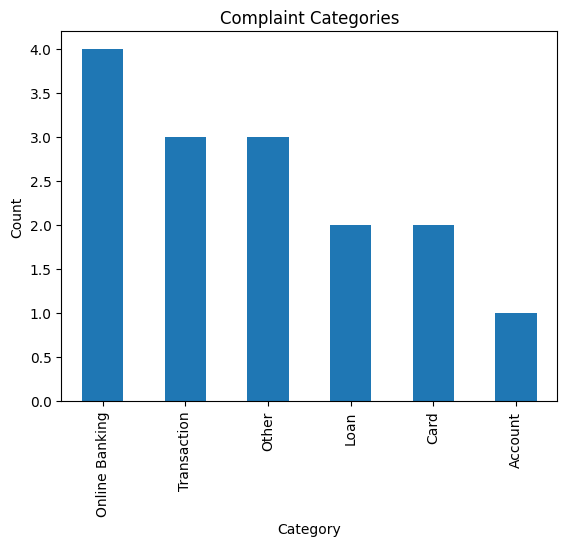

In [12]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")

plt.title("Complaint Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

In [13]:
print("===== Banking Complaint Analysis Report =====")

print("\nTotal Complaints:", len(df))

print("\nComplaint Categories")
print(df["Category"].value_counts())

print("\nSentiment Distribution")
print(df["Sentiment"].value_counts())

print("\nMost Frequent Words")
print(counter.most_common(10))


===== Banking Complaint Analysis Report =====

Total Complaints: 15

Complaint Categories
Category
Online Banking    4
Transaction       3
Other             3
Loan              2
Card              2
Account           1
Name: count, dtype: int64

Sentiment Distribution
Sentiment
Neutral     7
Negative    5
Positive    3
Name: count, dtype: int64

Most Frequent Words
[('banking', 4), ('failed', 2), ('loan', 2), ('account', 2), ('card', 2), ('payment', 2), ('transaction', 1), ('amount', 1), ('deducted', 1), ('approval', 1)]


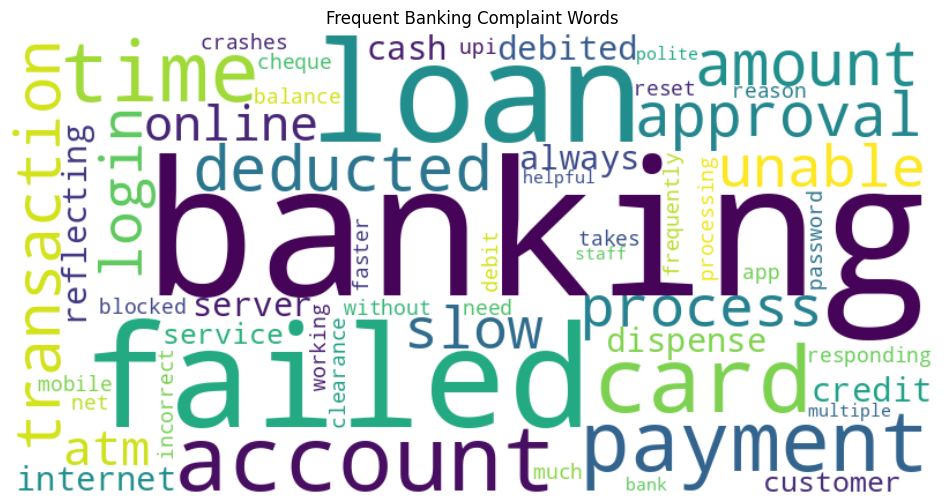

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned complaints into one string
text = " ".join(df["Clean_Complaint"])

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Frequent Banking Complaint Words")
plt.show()